<a href="https://colab.research.google.com/github/lovely-1512/Shrijal/blob/main/Churn_prediction_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 **1. Importing the depedencies**

In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split,cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_auc_score,ConfusionMatrixDisplay,RocCurveDisplay
import pickle
sns.set_theme(style="whitegrid", palette="Set2")
RANDOM_STATE = 42

In [105]:
df = pd.read_csv('https://github.com/YBIFoundation/Dataset/raw/main/TelecomCustomerChurn.csv')


In [106]:
df.shape

(7043, 21)

In [107]:
df.head()

,customerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Monthly,Yes,Manual,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Manual,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Monthly,Yes,Manual,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Monthly,Yes,Manual,70.70,151.65,Yes


In [108]:
df.tail()

,customerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Manual,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No,DSL,Yes,No,No,No,No,No,Monthly,Yes,Manual,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Monthly,Yes,Manual,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [109]:
df.describe()

,SeniorCitizen,Tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   Tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [111]:
pd.set_option("display.max_columns", None)

In [112]:
df.head(2)

,customerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Monthly,Yes,Manual,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Manual,56.95,1889.5,No


In [113]:
df=df.drop(columns =["customerID"])

In [114]:
df.head(3)

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Monthly,Yes,Manual,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Manual,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Monthly,Yes,Manual,53.85,108.15,Yes


In [115]:
df.columns

Index(['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [116]:
print(df["Gender"].unique())

print(df["SeniorCitizen"].unique())

['Female' 'Male']
[0 1]


In [117]:
numerical_features_list = ["Tenure","MonthlyCharges","TotalCharges"]

for col in df.columns:
  if col not in numerical_features_list:
    print(col, df[col].unique())
  print("-"*50)

Gender ['Female' 'Male']
--------------------------------------------------
SeniorCitizen [0 1]
--------------------------------------------------
Partner ['Yes' 'No']
--------------------------------------------------
Dependents ['No' 'Yes']
--------------------------------------------------
--------------------------------------------------
PhoneService ['No' 'Yes']
--------------------------------------------------
MultipleLines ['No' 'Yes']
--------------------------------------------------
InternetService ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity ['No' 'Yes']
--------------------------------------------------
OnlineBackup ['Yes' 'No']
--------------------------------------------------
DeviceProtection ['No' 'Yes']
--------------------------------------------------
TechSupport ['No' 'Yes']
--------------------------------------------------
StreamingTV ['No' 'Yes']
--------------------------------------------------
StreamingMovies [

In [118]:
print(df.isnull().sum())

Gender              0
SeniorCitizen       0
Partner             0
Dependents          0
Tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [119]:
df[df["TotalCharges"]==" "]

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No,No,No,No,No,No,Two year,No,Manual,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Manual,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No,No,No,No,No,No,Two year,No,Manual,25.75,,No
1340,Female,0,Yes,Yes,0,No,No,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No,No,No,No,No,No,Two year,No,Manual,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No,No,No,No,No,No,Two year,No,Manual,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No,No,No,No,No,No,Two year,No,Manual,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No,No,No,No,No,No,One year,Yes,Manual,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Manual,73.35,,No


In [120]:
len(df[df["TotalCharges"]==" "])

11

In [121]:
df["TotalCharges"] =df["TotalCharges"].replace({" ":"0.0"})

In [122]:
# Clean TotalCharges and create customer-value features.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Unique features: spending behaviour and customer lifecycle stage.
df["AvgMonthlySpend"] = df["TotalCharges"] / df["Tenure"].replace(0, 1)
df["TenureGroup"] = pd.cut(
    df["Tenure"], bins=[-1, 12, 24, 48, np.inf],
    labels=["New (0-12)", "Growing (13-24)", "Established (25-48)", "Loyal (49+)"]
)

In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Gender            7043 non-null   object  
 1   SeniorCitizen     7043 non-null   int64   
 2   Partner           7043 non-null   object  
 3   Dependents        7043 non-null   object  
 4   Tenure            7043 non-null   int64   
 5   PhoneService      7043 non-null   object  
 6   MultipleLines     7043 non-null   object  
 7   InternetService   7043 non-null   object  
 8   OnlineSecurity    7043 non-null   object  
 9   OnlineBackup      7043 non-null   object  
 10  DeviceProtection  7043 non-null   object  
 11  TechSupport       7043 non-null   object  
 12  StreamingTV       7043 non-null   object  
 13  StreamingMovies   7043 non-null   object  
 14  Contract          7043 non-null   object  
 15  PaperlessBilling  7043 non-null   object  
 16  PaymentMethod     7043 n

In [124]:
print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


**3. EDA**

In [125]:
df.columns

Index(['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'AvgMonthlySpend',
       'TenureGroup'],
      dtype='object')

In [126]:
df.shape

(7043, 22)

In [127]:
df.head(2)

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,TenureGroup
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Monthly,Yes,Manual,29.85,29.85,No,29.850000,New (0-12)
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Manual,56.95,1889.50,No,55.573529,Established (25-48)


In [128]:
df.describe()

,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges,AvgMonthlySpend
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304,64.698218
std,0.368612,24.559481,30.090047,2266.794470,30.270670
min,0.000000,0.000000,18.250000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,398.550000,35.649000
50%,0.000000,29.000000,70.350000,1394.550000,70.300000
75%,0.000000,55.000000,89.850000,3786.600000,90.174158
max,1.000000,72.000000,118.750000,8684.800000,121.400000


**Numerical Features - Analysis**

In [129]:
def plot_histogram(df,column_name):

  plt.figure(figsize=(5,3))
  sns.histplot(df[column_name],kde=True)
  plt.title("Distribution of {column_name}")

# calculate the value of mean and median for the columns
  col_mean = df[column_name].mean()
  col_median = df[column_name].median()

# Add vertical lines for mean and median
  plt.axvline(col_mean,color='red',linestyle="--",label="Mean")
  plt.axvline(col_median,color='green',linestyle="-",label="Median")
  plt.legend()
  plt.show()

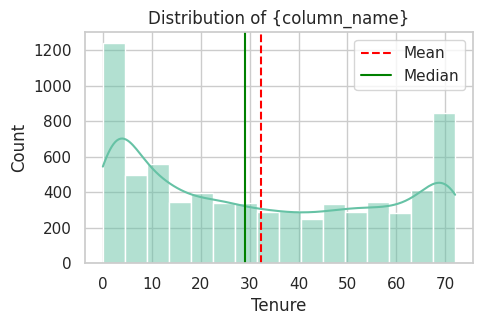

In [130]:
plot_histogram(df,"Tenure")

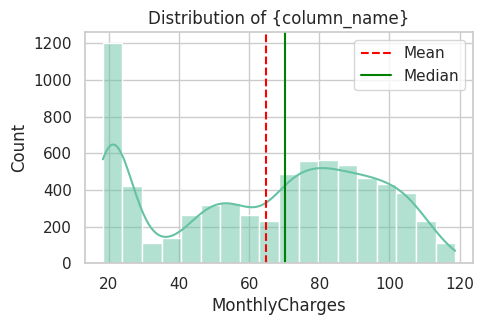

In [131]:
plot_histogram(df,"MonthlyCharges")

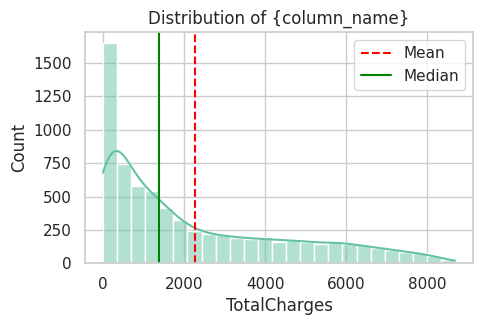

In [132]:
plot_histogram(df,"TotalCharges")

**Box plot for Numerical features**

In [133]:
def box_plot(df,column_name):
  plt.figure(figsize=(5,3))
  sns.boxplot(df[column_name])
  plt.title(f"Box plot of {column_name}")
  plt.ylabel(column_name)
  plt.show()

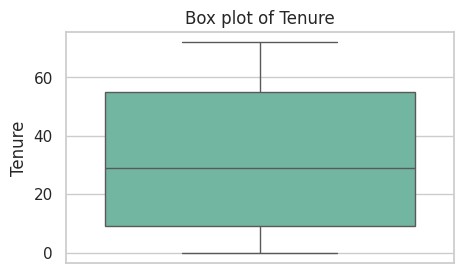

In [134]:
box_plot(df,"Tenure")

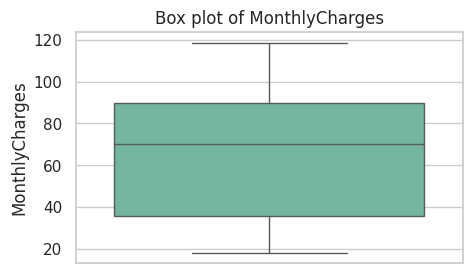

In [135]:
box_plot(df,"MonthlyCharges")

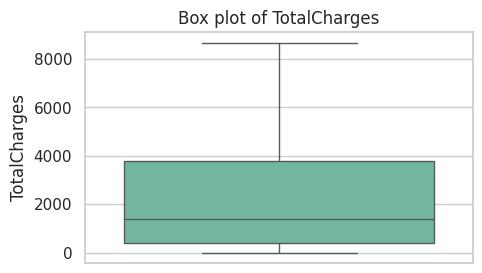

In [136]:
box_plot(df,"TotalCharges")

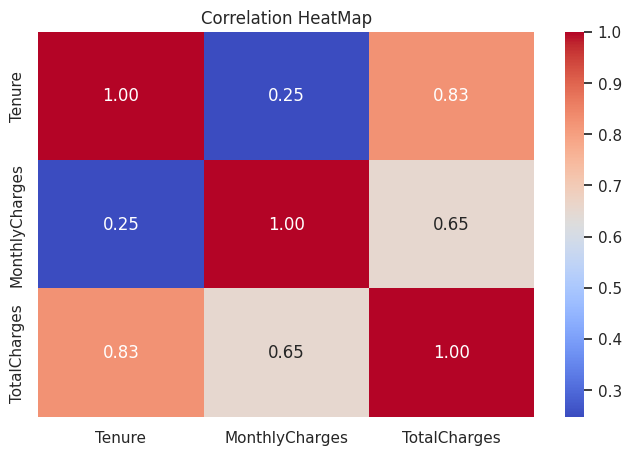

In [137]:
#correrelation matrix - heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df[["Tenure","MonthlyCharges", "TotalCharges"]].corr(),annot=True, cmap = "coolwarm",fmt=".2f")
plt.title("Correlation HeatMap")
plt.show()

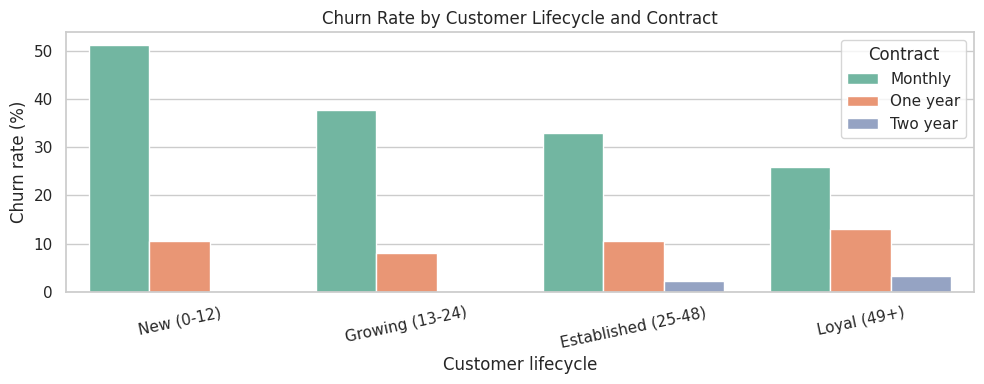

In [138]:
# Retention insight: contract type and lifecycle stage reveal where churn risk concentrates.
churn_by_segment = (
    df.assign(ChurnFlag=df["Churn"].map({"Yes": 1, "No": 0}))
      .groupby(["Contract", "TenureGroup"], observed=False)["ChurnFlag"]
      .mean().mul(100).reset_index(name="ChurnRate")
)
plt.figure(figsize=(10, 4))
sns.barplot(data=churn_by_segment, x="TenureGroup", y="ChurnRate", hue="Contract")
plt.title("Churn Rate by Customer Lifecycle and Contract")
plt.ylabel("Churn rate (%)")
plt.xlabel("Customer lifecycle")
plt.xticks(rotation=12)
plt.tight_layout()
plt.show()

**Categorical features - Analysis**

In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Gender            7043 non-null   object  
 1   SeniorCitizen     7043 non-null   int64   
 2   Partner           7043 non-null   object  
 3   Dependents        7043 non-null   object  
 4   Tenure            7043 non-null   int64   
 5   PhoneService      7043 non-null   object  
 6   MultipleLines     7043 non-null   object  
 7   InternetService   7043 non-null   object  
 8   OnlineSecurity    7043 non-null   object  
 9   OnlineBackup      7043 non-null   object  
 10  DeviceProtection  7043 non-null   object  
 11  TechSupport       7043 non-null   object  
 12  StreamingTV       7043 non-null   object  
 13  StreamingMovies   7043 non-null   object  
 14  Contract          7043 non-null   object  
 15  PaperlessBilling  7043 non-null   object  
 16  PaymentMethod     7043 n

**Countplot for categorical columns**

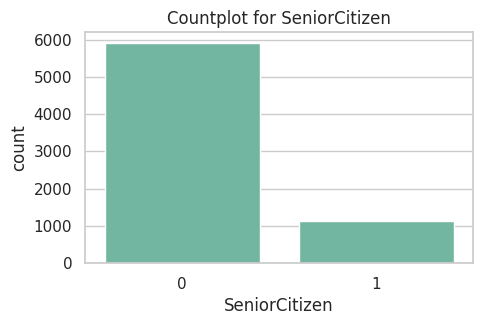

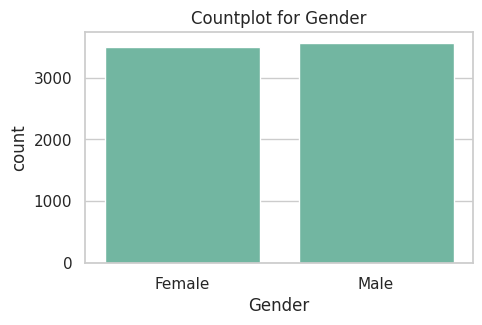

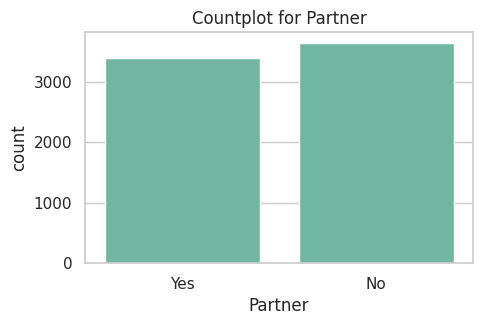

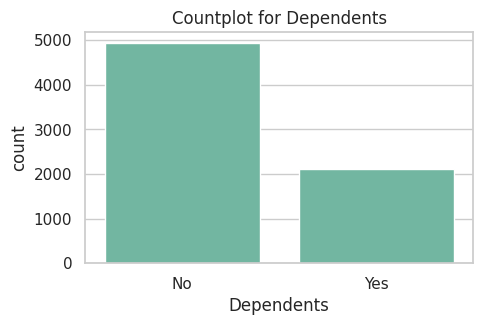

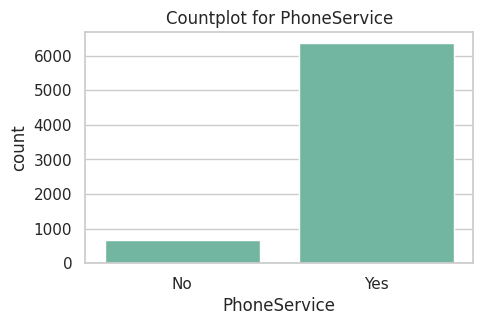

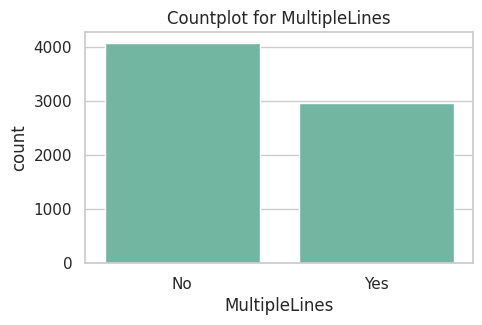

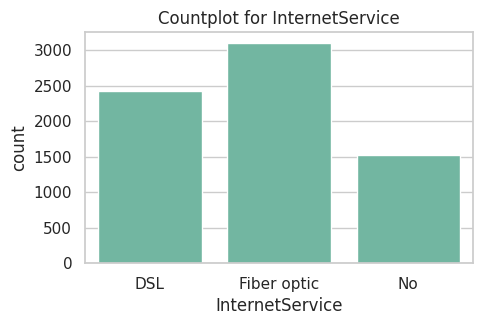

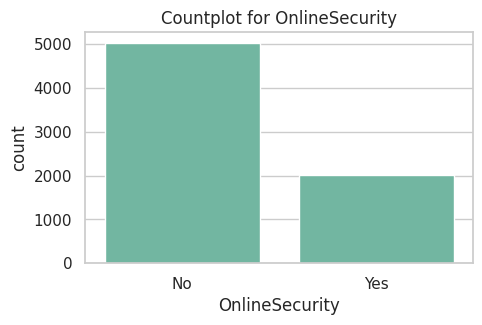

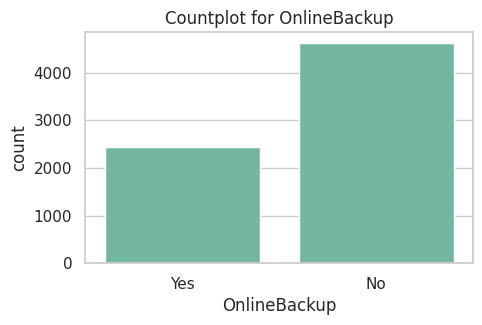

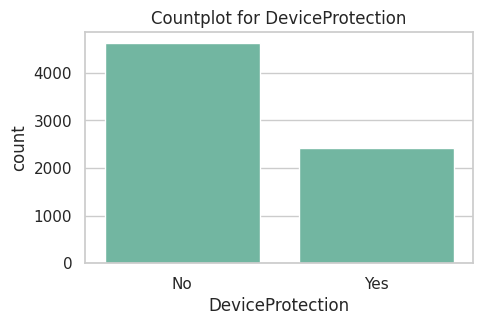

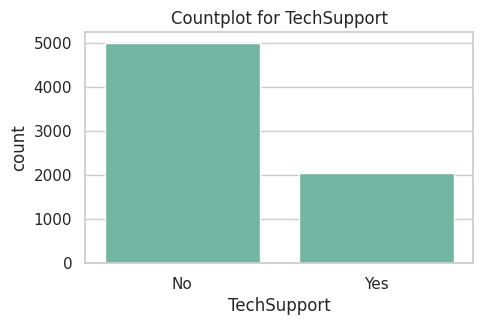

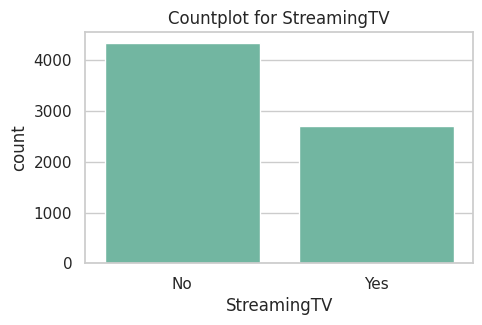

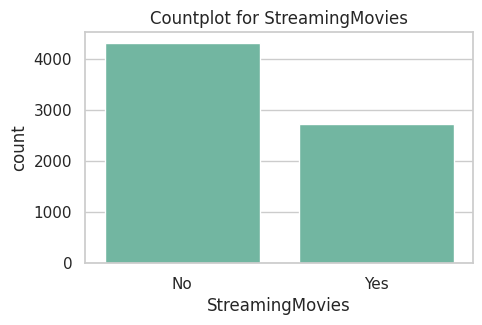

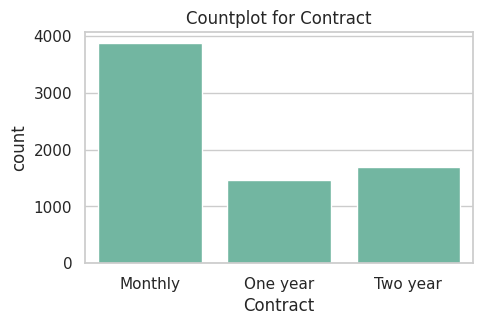

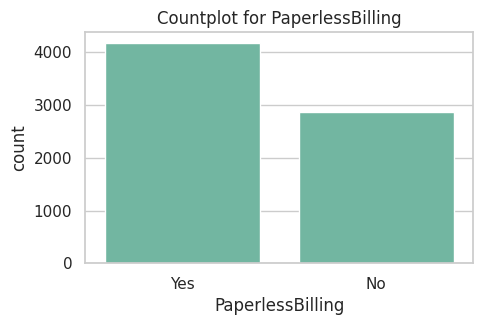

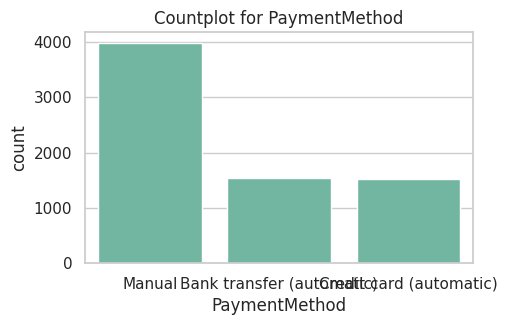

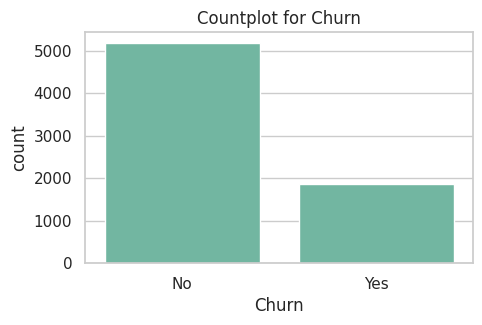

In [140]:
object_cols = df.select_dtypes(include="object").columns.to_list()

object_cols = ["SeniorCitizen"]+ object_cols

for col in object_cols:
  plt.figure(figsize=(5,3))
  sns.countplot(x=df[col])
  plt.title(f"Countplot for {col}")
  plt.show()

**4.Data Preprocessing**

In [141]:
df.head(3)

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,TenureGroup
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Monthly,Yes,Manual,29.85,29.85,No,29.850000,New (0-12)
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Manual,56.95,1889.50,No,55.573529,Established (25-48)
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Monthly,Yes,Manual,53.85,108.15,Yes,54.075000,New (0-12)


**Label encoding of target column**

In [142]:
df["Churn"]= df["Churn"].replace({"Yes":1, "No":0})

/tmp/ipykernel_3413/322619632.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Churn"]= df["Churn"].replace({"Yes":1, "No":0})


In [143]:
df.head(3)

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,TenureGroup
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Monthly,Yes,Manual,29.85,29.85,0,29.850000,New (0-12)
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Manual,56.95,1889.50,0,55.573529,Established (25-48)
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Monthly,Yes,Manual,53.85,108.15,1,54.075000,New (0-12)


In [144]:
print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


**Label encoding of Categorical features**

In [145]:
object_columns = df.select_dtypes(include="object").columns
print(object_columns)

Index(['Gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [146]:
encoders ={}

# apply the encoding and store the encoders
for column in object_columns:
  label_encoder = LabelEncoder()
  df[column] = label_encoder.fit_transform(df[column])
  encoders[column] = label_encoder

# save the encoder in pickle file
  with open("encoders.pkl","wb") as file:
    pickle.dump(encoders,file)

In [147]:
encoders

{'Gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder()}

In [148]:
df.head()

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,TenureGroup
0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,2,29.85,29.85,0,29.850000,New (0-12)
1,1,0,0,0,34,1,0,0,1,0,1,0,0,0,1,0,2,56.95,1889.50,0,55.573529,Established (25-48)
2,1,0,0,0,2,1,0,0,1,1,0,0,0,0,0,1,2,53.85,108.15,1,54.075000,New (0-12)
3,1,0,0,0,45,0,0,0,1,0,1,1,0,0,1,0,0,42.30,1840.75,0,40.905556,Established (25-48)
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1,75.825000,New (0-12)


**Training and Test data split**

In [149]:
#splitting the features and target
X = df.drop(columns=["Churn"])
y = df["Churn"]
print(X)

      Gender  SeniorCitizen  Partner  Dependents  Tenure  PhoneService  \
0          0              0        1           0       1             0   
1          1              0        0           0      34             1   
2          1              0        0           0       2             1   
3          1              0        0           0      45             0   
4          0              0        0           0       2             1   
...      ...            ...      ...         ...     ...           ...   
7038       1              0        1           1      24             1   
7039       0              0        1           1      72             1   
7040       0              0        1           1      11             0   
7041       1              1        1           0       4             1   
7042       1              0        0           0      66             1   

      MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0                 0                0     

In [150]:
# split training and test data
X = df.drop(columns=["Churn"])
y = df["Churn"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)


In [151]:
print(y_train.shape)

(5634,)


In [152]:
print(y_train.value_counts())

Churn
0    4139
1    1495
Name: count, dtype: int64


**Synthetic Minority OverSampling TEchnique**

In [153]:
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)


In [154]:
# This assumes 'encoders.pkl' exists and contains encoders for other categorical features.
try:
    with open("encoders.pkl", "rb") as f:
        encoders = pickle.load(f)
except FileNotFoundError:
    encoders = {}
if 'TenureGroup' in X_train.columns:
    if X_train['TenureGroup'].dtype.name == 'category' or isinstance(X_train['TenureGroup'].iloc[0], str):
        label_encoder_tenure_group = LabelEncoder()
        X_train.loc[:, 'TenureGroup'] = label_encoder_tenure_group.fit_transform(X_train['TenureGroup'])
        X_test.loc[:, 'TenureGroup'] = label_encoder_tenure_group.transform(X_test['TenureGroup'])
        encoders['TenureGroup'] = label_encoder_tenure_group

        # Save the updated encoders dictionary to include 'TenureGroup' encoder
        with open("encoders.pkl", "wb") as f:
            pickle.dump(encoders, f)

# Now apply SMOTE
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

/tmp/ipykernel_3413/600913722.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 1 1 ... 0 1 3]' has dtype incompatible with category, please explicitly cast to a compatible dtype first.
  X_train.loc[:, 'TenureGroup'] = label_encoder_tenure_group.fit_transform(X_train['TenureGroup'])
/tmp/ipykernel_3413/600913722.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[2 3 0 ... 3 2 2]' has dtype incompatible with category, please explicitly cast to a compatible dtype first.
  X_test.loc[:, 'TenureGroup'] = label_encoder_tenure_group.transform(X_test['TenureGroup'])


In [155]:
print(y_train_smote.shape)

(8278,)


In [156]:
print(y_train_smote.value_counts())

Churn
0    4139
1    4139
Name: count, dtype: int64


**5. Model Training**

In [157]:
from xgboost import XGBClassifier

In [158]:
# Dictionary of models

models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=8, min_samples_leaf=2,random_state = 42),
    "Random Forest": RandomForestClassifier(n_estimators=350, max_depth=14, min_samples_leaf=2,max_features= "sqrt",random_state = 42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=250, max_depth=4, learning_rate=0.05,subsample=0.85, colsample_bytree=0.85,eval_metric= "logloss",random_state = 42)
}

In [159]:
# DICTIONARY TO STORE THE CROSS-VALIDATION RESULTS
cv_scores = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# perform 5-fold cross validation for each model
for model_name, model in models.items():
    scores = cross_val_score(model, X_train_smote, y_train_smote, cv=cv, scoring="roc_auc")
    cv_scores[model_name] = scores
    print(f"{model_name}: ROC-AUC = {scores.mean():.3f} (+/- {scores.std():.3f})")

results = (pd.DataFrame(cv_scores)
             .agg(["mean", "std"]).T
             .rename(columns={"mean": "Mean ROC-AUC", "std": "Std. Dev."})
             .sort_values("Mean ROC-AUC", ascending=False))
display(results.style.format("{:.3f}"))

Decision Tree: ROC-AUC = 0.861 (+/- 0.007)
Random Forest: ROC-AUC = 0.922 (+/- 0.004)
XGBoost: ROC-AUC = 0.919 (+/- 0.005)


,Mean ROC-AUC,Std. Dev.
Random Forest,0.922,0.004
XGBoost,0.919,0.006
Decision Tree,0.861,0.008


In [160]:
cv_scores

{'Decision Tree': array([0.85483836, 0.85447808, 0.85674476, 0.8704356 , 0.86878319]),
 'Random Forest': array([0.91656238, 0.91861756, 0.92783379, 0.92393422, 0.92287618]),
 'XGBoost': array([0.91350878, 0.91353138, 0.92131307, 0.92750556, 0.92123107])}

**Random Forest gives the highest accuracy compared to other models with default parameters**

In [161]:
rfc = RandomForestClassifier(n_estimators=350, max_depth=14, min_samples_leaf=2,
    max_features="sqrt",random_state=42, n_jobs=-1)

In [162]:
rfc.fit(X_train_smote, y_train_smote)

RandomForestClassifier(max_depth=14, min_samples_leaf=2, n_estimators=350,
                       n_jobs=-1, random_state=42)

In [163]:
print(y_test.value_counts())

Churn
0    1035
1     374
Name: count, dtype: int64


**Model Evaluation**

Test Accuracy : 77.43%
Test ROC-AUC  : 0.831

Classification report:
               precision    recall  f1-score   support

           0       0.87      0.81      0.84      1035
           1       0.56      0.68      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.77      0.78      1409



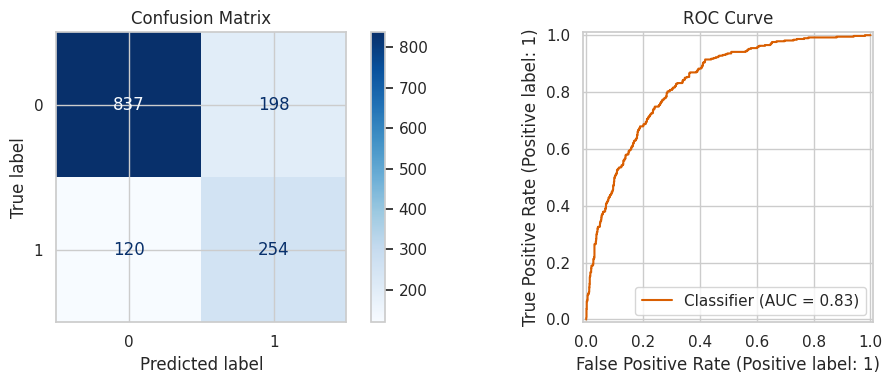

In [164]:
# evaluate on test data
y_test_pred = rfc.predict(X_test)
y_test_prob = rfc.predict_proba(X_test)[:, 1]

print(f"Test Accuracy : {accuracy_score(y_test, y_test_pred):.2%}")
print(f"Test ROC-AUC  : {roc_auc_score(y_test, y_test_prob):.3f}")
print("\nClassification report:\n", classification_report(y_test, y_test_pred))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion Matrix")
RocCurveDisplay.from_predictions(y_test, y_test_prob, ax=axes[1], color="#d95f02")
axes[1].set_title("ROC Curve")
plt.tight_layout()
plt.show()

In [165]:
# save the trained model as a pickle file
model_data = {"model": rfc, "features_names": X.columns.tolist()}


with open("customer_churn_model.pkl", "wb") as f:
  pickle.dump(model_data, f)

**Load the saved model and build a Predictive System**

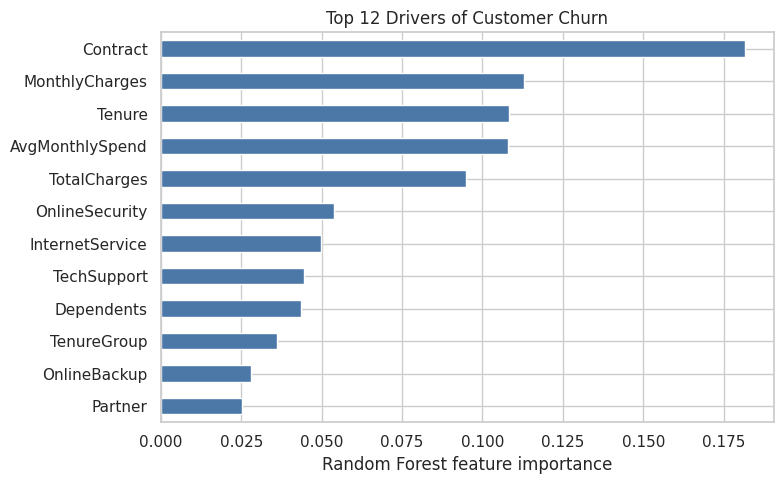

In [166]:
feature_importance = (pd.Series(rfc.feature_importances_, index=X.columns)
                        .sort_values(ascending=False).head(12)
                        .sort_values())
plt.figure(figsize=(8, 5))
feature_importance.plot(kind="barh", color="#4c78a8")
plt.title("Top 12 Drivers of Customer Churn")
plt.xlabel("Random Forest feature importance")
plt.tight_layout()
plt.show()

In [167]:
# load teh saved model and the feature names

with open("customer_churn_model.pkl", "rb") as f:
  model_data = pickle.load(f)

loaded_model = model_data["model"]
feature_names = model_data["features_names"]

In [168]:
print(loaded_model)

RandomForestClassifier(max_depth=14, min_samples_leaf=2, n_estimators=350,
                       n_jobs=-1, random_state=42)


In [169]:
print(feature_names)

['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'TenureGroup']


In [176]:
input_data = {
    'Gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'Tenure': 1,
    'PhoneService': 'No',
    'MultipleLines': 'No',
    'InternetService': 'DSL',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Monthly',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Manual',
    'MonthlyCharges': 70,
    'TotalCharges': 200,
    'AvgMonthlySpend': 35,
    'TenureGroup': 'New (0-12)'
  }


input_data_df = pd.DataFrame([input_data])

with open("encoders.pkl", "rb") as f:
  encoders = pickle.load(f)


# encode categorical featires using teh saved encoders
for column, encoder in encoders.items():
  input_data_df[column] = encoder.transform(input_data_df[column])

# make a prediction
prediction = loaded_model.predict(input_data_df)
pred_prob = loaded_model.predict_proba(input_data_df)

print(prediction)

# results
print(f"Prediction: {'Churn' if prediction[0] == 1 else 'No Churn'}")
print(f"Prediciton Probability: {pred_prob}")

[1]
Prediction: Churn
Prediciton Probability: [[0.49256729 0.50743271]]


In [177]:
# Convert one customer record into a personalised retention-risk decision.
input_df = pd.DataFrame([input_data])
input_df["TotalCharges"] = pd.to_numeric(input_df["TotalCharges"], errors="coerce").fillna(0)
input_df["AvgMonthlySpend"] = input_df["TotalCharges"] / input_df["Tenure"].replace(0, 1)
input_df["TenureGroup"] = pd.cut(input_df["Tenure"], bins=[-1, 12, 24, 48, np.inf],
                                  labels=["New (0-12)", "Growing (13-24)", "Established (25-48)", "Loyal (49+)"])

for column, encoder in encoders.items():
    input_df[column] = encoder.transform(input_df[column])

input_df = input_df[feature_names]
churn_probability = loaded_model.predict_proba(input_df)[0, 1]
risk_band = "High" if churn_probability >= 0.65 else "Medium" if churn_probability >= 0.35 else "Low"
print(f"Churn probability: {churn_probability:.1%}")
print(f"Retention risk: {risk_band}")

Churn probability: 71.0%
Retention risk: High
